#  Import Libraries


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load the DataSet

In [7]:
df = pd.read_csv("C:/Semester Materials/Machine Learning/GitHub/data/Heart_Disease_DataSet.csv")

# Explore the DataSet

In [8]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [9]:
df.shape

(1025, 14)

# Fix the missing Values 

In [13]:
df["ca"].fillna(df["ca"].median(),inplace = True)
df["thal"].fillna(df["thal"].median(), inplace = True)

C:\Users\maduw\AppData\Local\Temp\ipykernel_20988\1429810762.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["ca"].fillna(df["ca"].median(),inplace = True)
C:\Users\maduw\AppData\Local\Temp\ipykernel_20988\1429810762.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For ex

# Confirm all missing values are now gone

In [14]:
print("=== Missing Values After Fix ===")
print(df.isnull().sum().sum(), "missing values remaining")
print("\nAll missing values handled successfully! ✓")

=== Missing Values After Fix ===
0 missing values remaining

All missing values handled successfully! ✓


# Convert target to binary

In [17]:
# ================================================
# Cell 5 — Convert target column to binary (0 or 1)
# ================================================

# Check the original target values first
print("=== Original Target Values ===")
print(df["target"].value_counts().sort_index())
print(f"\nUnique values: {sorted(df['target'].unique())}")

=== Original Target Values ===
target
0    499
1    526
Name: count, dtype: int64

Unique values: [np.int64(0), np.int64(1)]


In [18]:
# ================================================
# Cell 5 — Confirm target is already binary
# ================================================

print("=== Target Column Check ===")
print(df["target"].value_counts().sort_index())
print(f"\nUnique values: {sorted(df['target'].unique())}")
print(f"\nTotal patients: {len(df)}")
print(f"Patients WITHOUT disease (0): {(df['target']==0).sum()} ({(df['target']==0).mean()*100:.1f}%)")
print(f"Patients WITH disease    (1): {(df['target']==1).sum()} ({(df['target']==1).mean()*100:.1f}%)")

# Target is already binary — no conversion needed!
print("\nTarget is already binary (0/1) — ready for ML!")

=== Target Column Check ===
target
0    499
1    526
Name: count, dtype: int64

Unique values: [np.int64(0), np.int64(1)]

Total patients: 1025
Patients WITHOUT disease (0): 499 (48.7%)
Patients WITH disease    (1): 526 (51.3%)

Target is already binary (0/1) — ready for ML!


In [19]:
# ================================================
# Cell 6 — One-Hot Encode categorical columns
# ================================================

# These columns are categorical — they represent categories not numbers
# cp = chest pain type (0,1,2,3)
# restecg = resting ECG results (0,1,2)
# slope = slope of ST segment (0,1,2)
# thal = thalassemia type (0,1,2,3)

print("=== Before Encoding ===")
print(f"Dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")

# Apply one-hot encoding to categorical columns
df = pd.get_dummies(df, columns=["cp", "restecg", "slope", "thal"], drop_first=True)

print("\n=== After Encoding ===")
print(f"Dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")

=== Before Encoding ===
Dataset shape: (1025, 14)
Columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

=== After Encoding ===
Dataset shape: (1025, 20)
Columns: ['age', 'sex', 'trestbps', 'chol', 'fbs', 'thalach', 'exang', 'oldpeak', 'ca', 'target', 'cp_1', 'cp_2', 'cp_3', 'restecg_1', 'restecg_2', 'slope_1', 'slope_2', 'thal_1', 'thal_2', 'thal_3']


In [20]:
# ================================================
# Cell 7 — Feature Scaling + Train/Test Split
# ================================================

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Separate features (X) and target (y)
X = df.drop("target", axis=1)
y = df["target"]

print(f"Features shape: {X.shape}")
print(f"Target shape:   {y.shape}")

# Split into 80% training and 20% testing
# random_state=42 ensures same split every time
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\n=== Train/Test Split ===")
print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples:  {X_test.shape[0]}")

# Apply StandardScaler — makes all features same scale
# Important because age (20-80) and cholesterol (100-400) 
# are on very different scales
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f"\n=== Scaling Done ===")
print("All features scaled successfully!")
print("X_train and X_test are ready for ML models!")


Features shape: (1025, 19)
Target shape:   (1025,)

=== Train/Test Split ===
Training samples: 820
Testing samples:  205

=== Scaling Done ===
All features scaled successfully!
X_train and X_test are ready for ML models!


In [21]:
# ================================================
# Cell 8 — Train the Random Forest Model
# ================================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             confusion_matrix, classification_report)

# Create the Random Forest model
# n_estimators=100 means 100 decision trees voting together
# random_state=42 ensures same results every time
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    random_state=42
)

# Train the model on training data
rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")
print(f"Number of trees: {rf_model.n_estimators}")


Random Forest model trained successfully!
Number of trees: 100


In [22]:
# ================================================
# Cell 9 — Evaluate the Model
# ================================================

# Make predictions on test data
y_pred = rf_model.predict(X_test)

# Calculate all metrics
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)

print("=== Random Forest Results ===")
print(f"Accuracy  : {accuracy*100:.1f}%")
print(f"Precision : {precision*100:.1f}%")
print(f"Recall    : {recall*100:.1f}%")
print(f"F1 Score  : {f1*100:.1f}%")

print("\n=== Full Classification Report ===")
print(classification_report(y_test, y_pred,
      target_names=["No Disease", "Disease"]))

print("\n=== Confusion Matrix ===")
cm = confusion_matrix(y_test, y_pred)
print(cm)

=== Random Forest Results ===
Accuracy  : 98.5%
Precision : 100.0%
Recall    : 97.1%
F1 Score  : 98.5%

=== Full Classification Report ===
              precision    recall  f1-score   support

  No Disease       0.97      1.00      0.99       102
     Disease       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205


=== Confusion Matrix ===
[[102   0]
 [  3 100]]


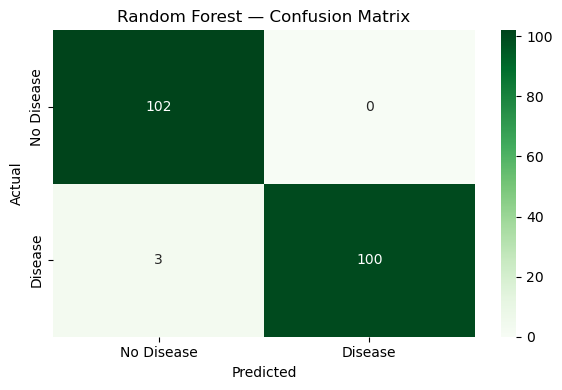

Confusion matrix saved!


In [24]:
# ================================================
# Cell 10 — Confusion Matrix Visualisation
# ================================================

import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=["No Disease", "Disease"],
            yticklabels=["No Disease", "Disease"])
plt.title("Random Forest — Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.savefig("rf_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("Confusion matrix saved!")


Random Forest AUC-ROC Score: 1.000


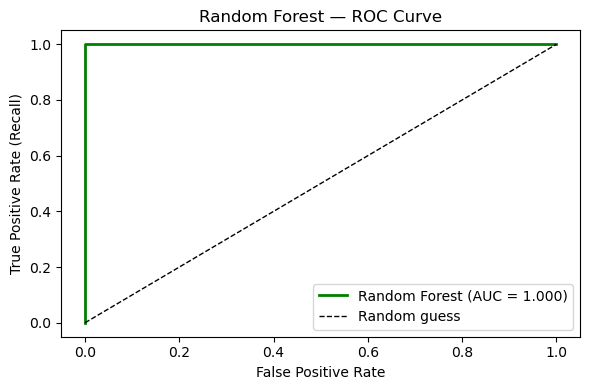

ROC curve saved!


In [25]:
# ================================================
# Cell 11 — ROC Curve & AUC Score
# ================================================

from sklearn.metrics import roc_curve, auc

# Get probability scores (not just 0/1 predictions)
y_prob = rf_model.predict_proba(X_test)[:, 1]

# Calculate ROC curve points
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

print(f"Random Forest AUC-ROC Score: {roc_auc:.3f}")

# Plot
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color="green", linewidth=2,
         label=f"Random Forest (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random guess")
plt.title("Random Forest — ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("rf_roc_curve.png", dpi=150, bbox_inches="tight")
plt.show()
print("ROC curve saved!")

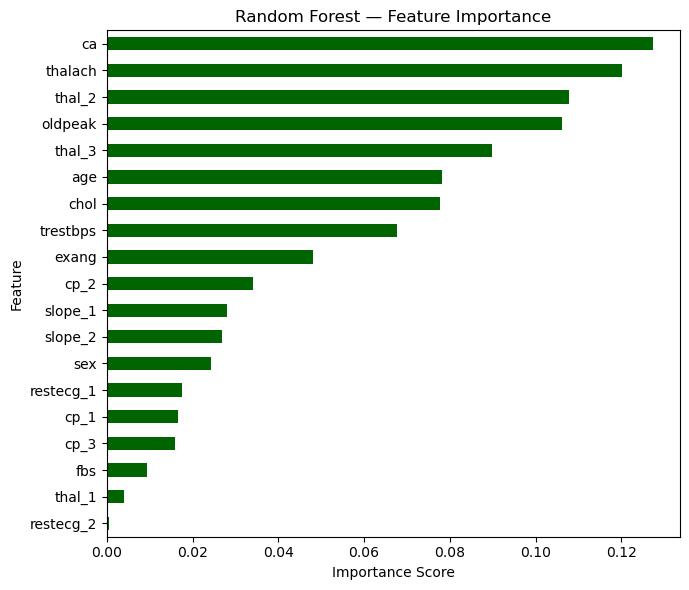

=== Top 5 Most Important Features ===
ca         0.127292
thalach    0.120213
thal_2     0.107775
oldpeak    0.106171
thal_3     0.089791
dtype: float64

Feature importance plot saved!


In [27]:
# ================================================
# Cell 12 — Feature Importance Plot
# ================================================
X_cols = df.drop("target", axis=1).columns.tolist()
# Random Forest tells us which features matter most
# Higher bar = more important for predicting heart disease

feat_imp = pd.Series(rf_model.feature_importances_, index=X_cols)
feat_imp_sorted = feat_imp.sort_values()

plt.figure(figsize=(7, 6))
feat_imp_sorted.plot(kind="barh", color="darkgreen")
plt.title("Random Forest — Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("rf_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

# Print top 5 most important features
print("=== Top 5 Most Important Features ===")
print(feat_imp.sort_values(ascending=False).head())
print("\nFeature importance plot saved!")